<a href="https://colab.research.google.com/github/mohammedwayiz18-jpg/GenerativeAI/blob/main/GAI_EXP02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

In [ ]:
from tensorflow.keras import layers, Model

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras import layers

input_img = layers.Input(shape=(784,))
ecode = layers.Dense(128, activation="relu")(input_img)
ecode

<KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.2282 - val_loss: 0.1501
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1333 - val_loss: 0.1196
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1150 - val_loss: 0.1088
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.1062 - val_loss: 0.1019
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1015 - val_loss: 0.0984
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0986 - val_loss: 0.0964
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0968 - val_loss: 0.0951
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0953 - val_loss: 0.0934
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0939 - val_loss: 0.0920
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0928 - val_loss: 0.0911
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


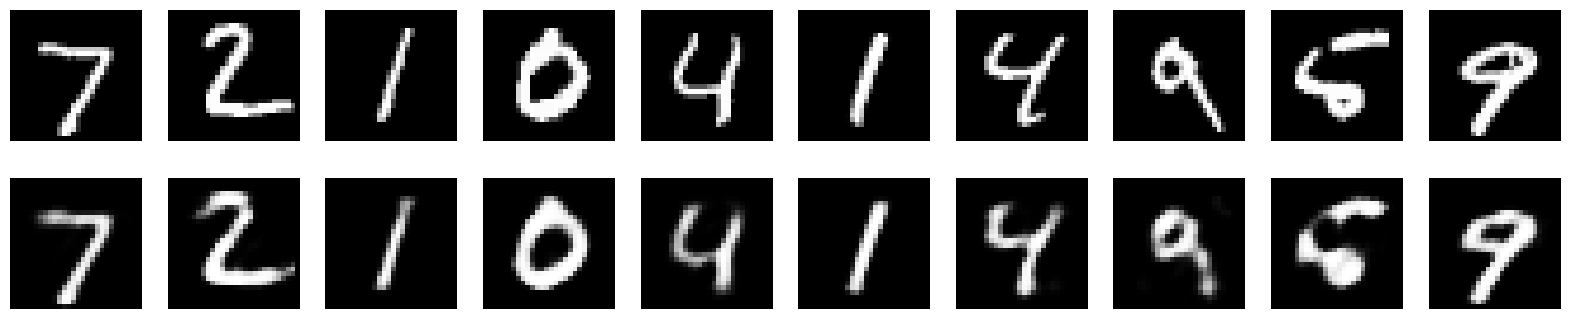

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values: 0-255 → 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images: 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# -------------------------
# Encoder
# -------------------------
input_img = layers.Input(shape=(784,))

encoded = layers.Dense(128, activation="relu")(input_img)
encoded = layers.Dense(32, activation="relu")(encoded)

# -------------------------
# Decoder
# -------------------------
decoded = layers.Dense(128, activation="relu")(encoded)
decoded = layers.Dense(784, activation="sigmoid")(decoded)

# Create Autoencoder
autoencoder = Model(input_img, decoded)

# Compile
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Train
autoencoder.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=256,
    validation_data=(x_test, x_test)
)

# Reconstruct test images
reconstructed = autoencoder.predict(x_test)

# -------------------------
# Display original vs reconstructed
# -------------------------

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.show()